In [1]:
import os 
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import h5py
import numpy as np 


from scipy.integrate import simpson
from scipy.optimize import curve_fit
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.lines import Line2D


In [2]:


# Fit the resolution data to a polynomial for extrapolation
def poly_func(x, a, b, c):
    return a * x**2 + b * x + c

# Create a function to get resolution for any energy
def get_resolution(e,popt):
    return np.maximum(poly_func(e, *popt), 1e-10)  # Ensure non-zero resolution


# Perform Gaussian broadening using convolution with energy-dependent widths
def gaussian_broadening(dos, energy, sigmas):
    broadened_dos = np.zeros_like(dos)
    for i in range(len(energy)):
        # Create a Gaussian kernel centered at each energy point with width sigmas[i]
        kernel = np.exp(-0.5 * ((energy - energy[i]) / sigmas[i])**2)
        kernel /= simpson(kernel, energy)  # Normalize the kernel to preserve area
        broadened_dos += dos[i] * kernel  # Convolve DOS with Gaussian kernel
    return broadened_dos

def apply_gaussian_broadening(dos_data,metric='dos total (nm2/ps)',unit_cell_atoms=1):
    energy = dos_data['Energy Transfer (meV)'].values
    dos = dos_data[metric].values

    resolution_data = pd.read_csv('../data/resolution.csv')
    res_energy = resolution_data['Energy (meV)'].values
    resolution = resolution_data['Resolution'].values
    popt, _ = curve_fit(poly_func, res_energy, resolution)
    
    # Create an array of sigmas for Gaussian broadening based on the resolution function
    sigmas = get_resolution(energy,popt) / np.sqrt(8 * np.log(2))  # Convert FWHM to sigma


    broadened_dos = gaussian_broadening(dos, energy, sigmas)

    # Area normalize both original and broadened DOS
    original_area = simpson(dos, energy)
    broadened_area = simpson(broadened_dos, energy)

    dos_normalized = dos / original_area
    broadened_dos_normalized = broadened_dos / broadened_area
    return 3*unit_cell_atoms*broadened_dos_normalized

In [3]:
def read_dos_gmx(results_directory):
    df_list=list()
    for dirname in os.listdir(results_directory):
        if not "prod" in dirname:
            continue
        data_directory=os.path.join(results_directory,dirname)
        for filename in os.listdir(data_directory):
            if not "dos" in filename or not "xvg" in filename:
                continue
            file_path=os.path.join(data_directory,filename)
            df_tmp=pd.read_csv(file_path,names=['Wave number $(cm^{-1})',"dos","dos(solid)","dos(diff)"],skiprows=26,sep='\s+')
            df_tmp["Temperature (K)"]=int(os.path.split(data_directory)[-1].split("_")[-1])
            df_tmp["subset"]=filename.split("_")[-1].split(".")[0]
            df_tmp['Energy Transfer (meV)']=df_tmp['Wave number $(cm^{-1})']*0.124
            dos=df_tmp["dos(solid)"].values
            energy=df_tmp["Energy Transfer (meV)"].values
            original_area = simpson(dos, energy)
            df_tmp["VDOS (1/meV)"] = df_tmp["dos(solid)"]/original_area
            df_list.append(df_tmp)
            
    df=pd.concat(df_list,ignore_index=True)
    return df

df_list=list()
for H2O_mol in [45,90,180,360,720,1440]:
    df_tmp=read_dos_gmx("../results/gromacs/pore/4nm/H2O/results/%d"%H2O_mol)
    df_tmp["H2O Molecules"]=H2O_mol
    df_list.append(df_tmp)
df_dos_gmx=pd.concat(df_list,ignore_index=True)
df_dos_gmx

,Wave number $(cm^{-1}),dos,dos(solid),dos(diff),Temperature (K),subset,Energy Transfer (meV),VDOS (1/meV),H2O Molecules
0,0.00000,0.073857,0.000000,0.073857,100,H2O,0.000000,0.000000,45
1,1.33426,0.074195,0.000346,0.073849,100,H2O,0.165448,0.000005,45
2,2.66851,0.074469,0.000644,0.073825,100,H2O,0.330895,0.000009,45
3,4.00277,0.075545,0.001760,0.073786,100,H2O,0.496343,0.000024,45
4,5.33703,0.077133,0.003402,0.073731,100,H2O,0.661792,0.000046,45
...,...,...,...,...,...,...,...,...,...
134995,3328.97000,12.082600,12.029800,0.052754,300,total,412.792280,0.001295,1440
134996,3330.30000,12.082800,12.030100,0.052712,300,total,412.957200,0.001295,1440
134997,3331.64000,12.082600,12.030000,0.052670,300,total,413.123360,0.001295,1440
134998,3332.97000,12.082500,12.029900,0.052628,300,total,413.288280,0.001295,1440


In [4]:
def read_rmsd_gmx(results_directory):
    df_list=list()
    for dirname in os.listdir(results_directory):
        if not "prod" in dirname:
            continue
        data_directory=os.path.join(results_directory,dirname)
        for filename in os.listdir(data_directory):
            if not "rmsd" in filename or not "xvg" in filename:
                continue
            file_path=os.path.join(data_directory,filename)
            df_tmp=pd.read_csv(file_path,names=['Time (ns)',"RMDS (nm)"],skiprows=18,sep='\s+')
            df_tmp["Temperature (K)"]=int(os.path.split(data_directory)[-1].split("_")[-1])
            df_tmp["subset"]=filename.split("_")[-1].split(".")[0]
            df_list.append(df_tmp)
    df=pd.concat(df_list,ignore_index=True)
    return df

df_list=list()
for H2O_mol in [45,90,180,360,720,1440]:
    df_tmp=read_rmsd_gmx("../results/gromacs/pore/4nm/H2O/results/%d"%H2O_mol)
    df_tmp["H2O Molecules"]=H2O_mol
    df_list.append(df_tmp)
df_rmsd_gmx=pd.concat(df_list,ignore_index=True)
df_rmsd_gmx

,Time (ns),RMDS (nm),Temperature (K),subset,H2O Molecules
0,0.000000,0.000000,100,H2O,45
1,0.000005,0.002696,100,H2O,45
2,0.000010,0.005224,100,H2O,45
3,0.000015,0.007545,100,H2O,45
4,0.000020,0.009766,100,H2O,45
...,...,...,...,...,...
540049,0.049980,0.605135,300,total,1440
540050,0.049985,0.605140,300,total,1440
540051,0.049990,0.605145,300,total,1440
540052,0.049995,0.605151,300,total,1440


(2, 3)


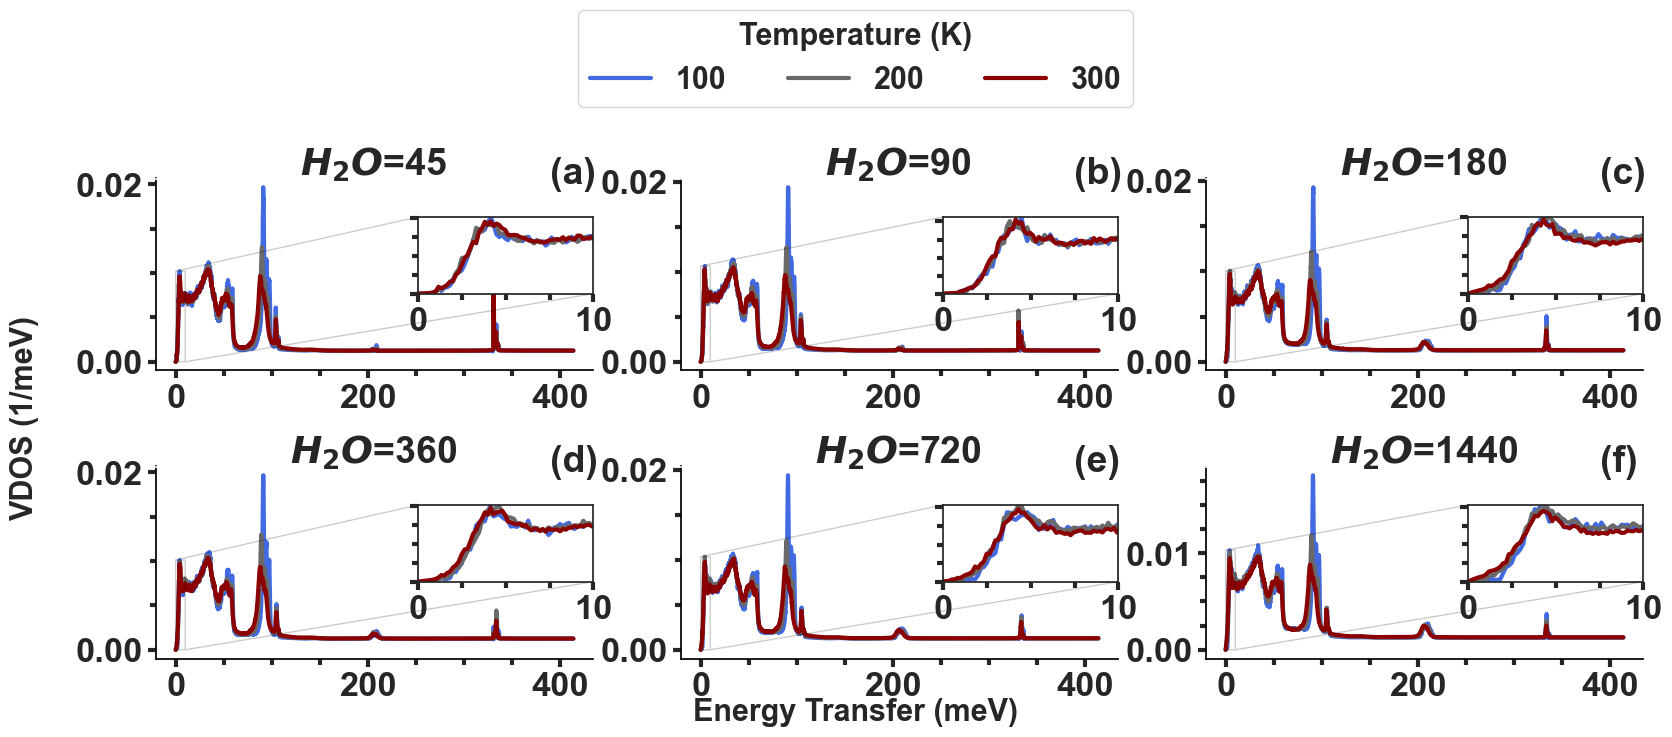

In [21]:
plt.rc('axes', linewidth=3, labelsize=22)
plt.rc('xtick', labelsize=22)  # fontsize of the x tick labels
plt.rc('ytick', labelsize=22)  # fontsize of the y tick labels
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'  # Axis labels
plt.rcParams['axes.titleweight'] = 'bold' 

sns.set_theme(font_scale=2.25)
sns.set_style("white")

def apply_ax_format(ax,xlabel="",ylabel="",legend=False,inset=False):
    if not inset:
        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
    ax.tick_params(which="both",direction='out', width=3, bottom=True, left=True)
    ax.grid(False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    if legend:
        plt.setp(ax.get_legend().get_texts(), fontsize='22') # for legend text
        plt.setp(ax.get_legend().get_title(), fontsize='22') # for legend title



H2O_mol_list=df_dos_gmx["H2O Molecules"].unique()

fig, axs = plt.subplots(ncols=3,nrows=2,figsize=(7*2.5,3*2))
palette=sns.color_palette("tab10")

labx=0.9
laby=0.975
index=["(%s)"%x for x in list("abcdefghijkl")]
print(axs.shape)
for i, H2O_mol in enumerate(H2O_mol_list):
    ax=axs[i//3,i%3]

    df_tmp=df_dos_gmx.query("`H2O Molecules` == %d and subset == 'total' and `Energy Transfer (meV)` < 1000 " % H2O_mol)
    if df_tmp.empty:
        ax.axis('off')
        ax.axis('tight')
        continue 

    ax.text(labx, laby, index[i],weight='bold' ,transform=ax.transAxes)

    sns.lineplot(data=df_tmp
                ,y="VDOS (1/meV)"
                ,x="Energy Transfer (meV)"
                ,ax=ax
                ,palette=["royalblue","dimgrey","darkred"]
                ,hue=df_tmp.columns[4]
                ,legend=i==0
                 ,lw=3
           )

    apply_ax_format(ax,legend=i==0)
   
    ax.set_title("$H_2O$=%d " % H2O_mol, y=0.975)
    if i ==0:
        sns.move_legend(ax,'center',bbox_to_anchor=(0.5,1.1),ncol=3,bbox_transform=fig.transFigure,fontsize=22,title_fontsize=22)

    x1, x2, y1, y2 = 0, 10, 0, df_tmp.query("`Energy Transfer (meV)` < 10")["VDOS (1/meV)"].max()

    xw=0.4
    axins = ax.inset_axes(
        [0.6, 0.4,0.4, 0.4]
        ,xlim=(x1, x2)
        , ylim=(y1, y2)
        #,xticklabels=[]
        , yticklabels=[]
        #, transform=ax.transData
    )
    
    sns.lineplot(data=df_tmp
                ,y="VDOS (1/meV)"
                ,x='Energy Transfer (meV)'
                ,ax=axins
                ,palette=["royalblue","dimgrey","darkred"]
                ,hue="Temperature (K)"
#                   ,color=palette[j]
                ,legend=False
                 ,linewidth=3
           )
    
    ax.indicate_inset_zoom(axins, edgecolor="black",alpha=0.2)
    apply_ax_format(axins,inset=True)




ax.text(0.025, 0.5, "VDOS (1/meV)",weight='bold' ,transform=fig.transFigure,ha='center',va='center',fontsize=22,rotation='vertical')         
ax.text(0.5, 0.01, "Energy Transfer (meV)",weight='bold' ,transform=fig.transFigure,ha='center',va='center',fontsize=22)         

            
# set the spacing between subplots
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.95, 
                    top=0.9, 
                    wspace=0.2, 
                    hspace=0.5
                   )
plt.savefig("../figures/fig8.pdf", pad_inches=0.2,bbox_inches="tight")

In [54]:
df_dos_gmx.columns[6]

'Energy Transfer (meV)'